# 16 — Cooling Degree Days (Tmin): CV comparison

Tests whether **cumulative excess heat above a fixed threshold** (cooling degree days, CDD) produces better spatial discrimination than a simple **day count** (tropical nights).

Both metrics use Tmin with the same two absolute thresholds from notebook 15:

| Metric | Formula | Units |
|---|---|---|
| **TR20 count** | days where Tmin > 20 °C | nights / year |
| **TR25 count** | days where Tmin > 25 °C | nights / year |
| **CDD20** | Σ max(0, Tmin − 20 °C) | °C·days / year |
| **CDD25** | Σ max(0, Tmin − 25 °C) | °C·days / year |

CDD captures both **frequency** (how often Tmin exceeds the threshold) and **intensity** (by how much), whereas the count treats a night at 21 °C and one at 30 °C identically. The hypothesis is that accumulating the excess degrees produces a more spatially variable signal because small absolute differences in mean Tmin compound over many nights.

All metrics are computed as per-pixel annual means over 2003–2020 and aggregated to neighbourhoods by **population-weighted mean**. CV is compared across metrics and cities.

**Prerequisites:** `01b_data_acquisition_tmin`, population grids and neighbourhood boundaries.

## Setup

In [20]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city_tmin,
    load_neighbourhood_boundaries,
    _point_in_poly_mask,
)

DATA_DIR  = 'data'
CITY_KEYS = ['salvador', 'teresina', 'caceres']
POP_YEAR  = 2020
THRESHOLDS = {'CDD20': 20.0, 'CDD25': 25.0}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

# ---- Load Tmin series -------------------------------------------------------
tmins = {}
for c in CITY_KEYS:
    da = load_city_tmin(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    tmins[c] = da

# ---- Load neighbourhood boundaries -----------------------------------------
gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

# ---- Population grid loader -------------------------------------------------
def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

salvador: shape {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


## Helper functions

In [21]:
def compute_cdd(da, threshold):
    """Annual sum of max(0, da - threshold) per pixel. Returns (year, lat, lon)."""
    excess = (da - threshold).clip(min=0)
    return excess.resample(time='YS').sum(dim='time')


def compute_tropical_nights(da, threshold):
    """Annual count of days where da > threshold per pixel. Returns (year, lat, lon)."""
    return (da > threshold).resample(time='YS').sum(dim='time')


def popwt_aggregate(metric_map, pop_map, gdf, col):
    """
    Population-weighted mean of metric_map pixels within each neighbourhood polygon.
    Matches the approach in notebook 12.
    """
    pop_aligned = pop_map.interp(
        lat=metric_map.lat, lon=metric_map.lon, method='nearest'
    ).fillna(0)

    lats = metric_map.lat.values
    lons = metric_map.lon.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    lon_flat = lon_grid.ravel()
    lat_flat = lat_grid.ravel()
    val_flat = metric_map.values.ravel().astype(float)
    pop_flat = pop_aligned.values.ravel().astype(float)

    results = []
    for _, row in gdf.iterrows():
        mask  = _point_in_poly_mask(row.geometry, lon_flat, lat_flat)
        v     = val_flat[mask]
        p     = pop_flat[mask]
        valid = np.isfinite(v) & np.isfinite(p) & (p > 0)
        if valid.sum() > 0:
            results.append(float(np.average(v[valid], weights=p[valid])))
        else:
            finite_v = v[np.isfinite(v)]
            if len(finite_v) > 0:
                results.append(float(finite_v.mean()))
            else:
                cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
                dist2  = (lon_flat - cx) ** 2 + (lat_flat - cy) ** 2
                results.append(float(val_flat[np.argmin(dist2)]))

    result      = gdf.copy()
    result[col] = results
    return result


def safe_cv(series):
    m = series.mean()
    return series.std() / m if m > 0 else np.nan

## Compute metrics

For each city and each threshold: compute annual CDD and annual tropical-night count, then take the multi-year mean (2003–2020) per pixel.

In [22]:
pixel_metrics = {}  # city -> dict of mean-annual (lat, lon) maps

for c in CITY_KEYS:
    da = tmins[c]
    pm = {}
    for name, thr in THRESHOLDS.items():
        cdd_annual = compute_cdd(da, thr)
        tn_annual  = compute_tropical_nights(da, thr)
        pm[f'{name}_cdd']   = cdd_annual.mean(dim='time')
        pm[f'{name}_count'] = tn_annual.mean(dim='time')

    pixel_metrics[c] = pm

    print(
        f"{CITIES[c]['label']}  "
        f"CDD20={float(pm['CDD20_cdd'].mean()):.1f} °C·d  "
        f"TR20={float(pm['CDD20_count'].mean()):.1f} d  "
        f"CDD25={float(pm['CDD25_cdd'].mean()):.1f} °C·d  "
        f"TR25={float(pm['CDD25_count'].mean()):.1f} d"
    )

Salvador, Brazil  CDD20=263.3 °C·d  TR20=102.5 d  CDD25=4.5 °C·d  TR25=4.9 d
Teresina, Brazil  CDD20=1179.0 °C·d  TR20=356.0 d  CDD25=8.1 °C·d  TR25=16.3 d
Cáceres, Brazil  CDD20=631.1 °C·d  TR20=242.3 d  CDD25=3.3 °C·d  TR25=5.8 d


## Aggregate to neighbourhoods (population-weighted mean)

In [23]:
metric_cols = ['CDD20_cdd', 'CDD20_count', 'CDD25_cdd', 'CDD25_count']

nbhd_tables = {}

for c in CITY_KEYS:
    gdf      = gdfs[c]
    pop_grid = load_pop_grid(c, POP_YEAR)
    pm       = pixel_metrics[c]

    df = gdf[['name']].copy()
    for col in metric_cols:
        agg     = popwt_aggregate(pm[col], pop_grid, gdf, col)
        df[col] = agg[col].values

    df = df.dropna().reset_index(drop=True)
    nbhd_tables[c] = df

    print(
        f"{CITIES[c]['label']:25s}  {len(df):3d} neighbourhoods  "
        f"CDD20 {df['CDD20_cdd'].min():.1f}–{df['CDD20_cdd'].max():.1f} °C·d  "
        f"TR20  {df['CDD20_count'].min():.1f}–{df['CDD20_count'].max():.1f} nights  "
        f"CDD25 {df['CDD25_cdd'].min():.1f}–{df['CDD25_cdd'].max():.1f} °C·d  "
        f"TR25  {df['CDD25_count'].min():.1f}–{df['CDD25_count'].max():.1f} nights"
    )

Salvador, Brazil            22 neighbourhoods  CDD20 0.0–835.8 °C·d  TR20  0.0–291.8 nights  CDD25 0.0–25.7 °C·d  TR25  0.0–24.5 nights
Teresina, Brazil           112 neighbourhoods  CDD20 1269.9–1495.1 °C·d  TR20  347.7–360.4 nights  CDD25 12.3–48.3 °C·d  TR25  23.6–67.4 nights
Cáceres, Brazil             43 neighbourhoods  CDD20 704.6–788.3 °C·d  TR20  252.4–262.2 nights  CDD25 4.9–10.9 °C·d  TR25  8.1–15.1 nights


## Coefficient of variation comparison

CV = σ / μ across neighbourhoods within each city.  Higher CV = more spatial discrimination.

The key comparison is **CDD vs count** at each threshold: does accumulating the excess degree-days over the threshold improve on the simple binary count?

In [24]:
metric_labels = {
    'CDD20_cdd':   'CDD20  (°C·d)',
    'CDD20_count': 'TR20 count  (nights)',
    'CDD25_cdd':   'CDD25  (°C·d)',
    'CDD25_count': 'TR25 count  (nights)',
}

rows = []
for c in CITY_KEYS:
    df  = nbhd_tables[c]
    row = {'City': CITIES[c]['label'], 'N': len(df)}
    for col, label in metric_labels.items():
        row[f'{label} mean'] = df[col].mean()
        row[f'{label} CV']   = safe_cv(df[col])
    rows.append(row)

summary = pd.DataFrame(rows).set_index('City')

cv_cols   = [f'{l} CV'   for l in metric_labels.values()]
mean_cols = [f'{l} mean' for l in metric_labels.values()]

fmt = {'N': '{:.0f}'}
fmt.update({c: '{:.3f}' for c in cv_cols})
fmt.update({c: '{:.2f}' for c in mean_cols})

display(
    summary[['N'] + mean_cols + cv_cols]
    .style
    .format(fmt)
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .set_caption(
        'CV = std / mean across neighbourhoods  |  Higher CV = more spatial discrimination  |  '
        'Multi-year means 2003–2020, pop-weighted aggregation'
    )
    .set_table_styles(table_styles)
)

,N,CDD20 (°C·d) mean,TR20 count (nights) mean,CDD25 (°C·d) mean,TR25 count (nights) mean,CDD20 (°C·d) CV,TR20 count (nights) CV,CDD25 (°C·d) CV,TR25 count (nights) CV
City,,,,,,,,,
"Salvador, Brazil",22,517.73,187.41,14.30,13.24,0.458,0.478,0.414,0.427
"Teresina, Brazil",112,1399.26,359.77,29.47,46.99,0.039,0.004,0.284,0.219
"Cáceres, Brazil",43,753.70,257.21,7.78,11.82,0.031,0.012,0.213,0.157


## CV comparison bar chart

Paired bars for each city show CDD vs count side-by-side. The shared y-axis allows direct comparison of effect size across cities.

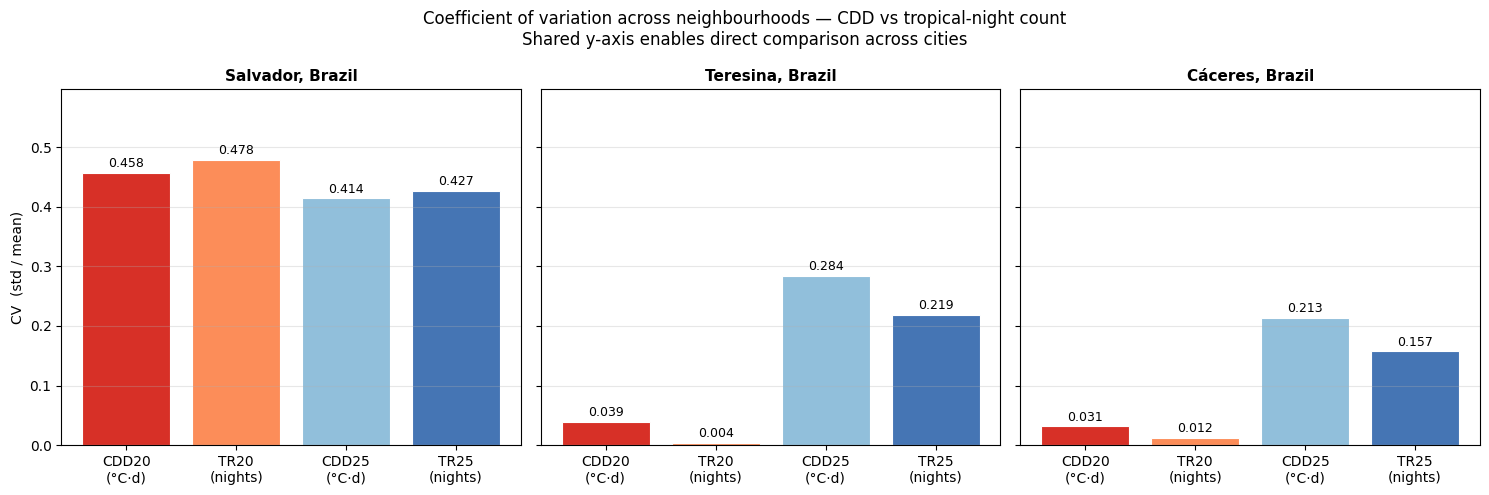

In [25]:
all_cvs = {}
for c in CITY_KEYS:
    df = nbhd_tables[c]
    all_cvs[c] = [safe_cv(df[col]) for col in metric_cols]

global_cv_max = max(v for city_cvs in all_cvs.values() for v in city_cvs if np.isfinite(v))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle(
    'Coefficient of variation across neighbourhoods — CDD vs tropical-night count\n'
    'Shared y-axis enables direct comparison across cities',
    fontsize=12,
)

colors      = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']
short_labels = ['CDD20\n(°C·d)', 'TR20\n(nights)', 'CDD25\n(°C·d)', 'TR25\n(nights)']

for ax, c in zip(axes, CITY_KEYS):
    cvs  = all_cvs[c]
    bars = ax.bar(short_labels, cvs, color=colors, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, cvs):
        if np.isfinite(v):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                v + global_cv_max * 0.01,
                f'{v:.3f}',
                ha='center', va='bottom', fontsize=9,
            )
    ax.set_title(CITIES[c]['label'], fontsize=11, fontweight='bold')
    ax.set_ylim(0, global_cv_max * 1.25)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('CV  (std / mean)', fontsize=10)
plt.tight_layout()
plt.show()

## Does CDD improve on count? — paired scatter

Each point is one neighbourhood. x = count-based neighbourhood rank, y = CDD-based neighbourhood rank. Points off the diagonal indicate CDD produces different neighbourhood rankings from the simple count.

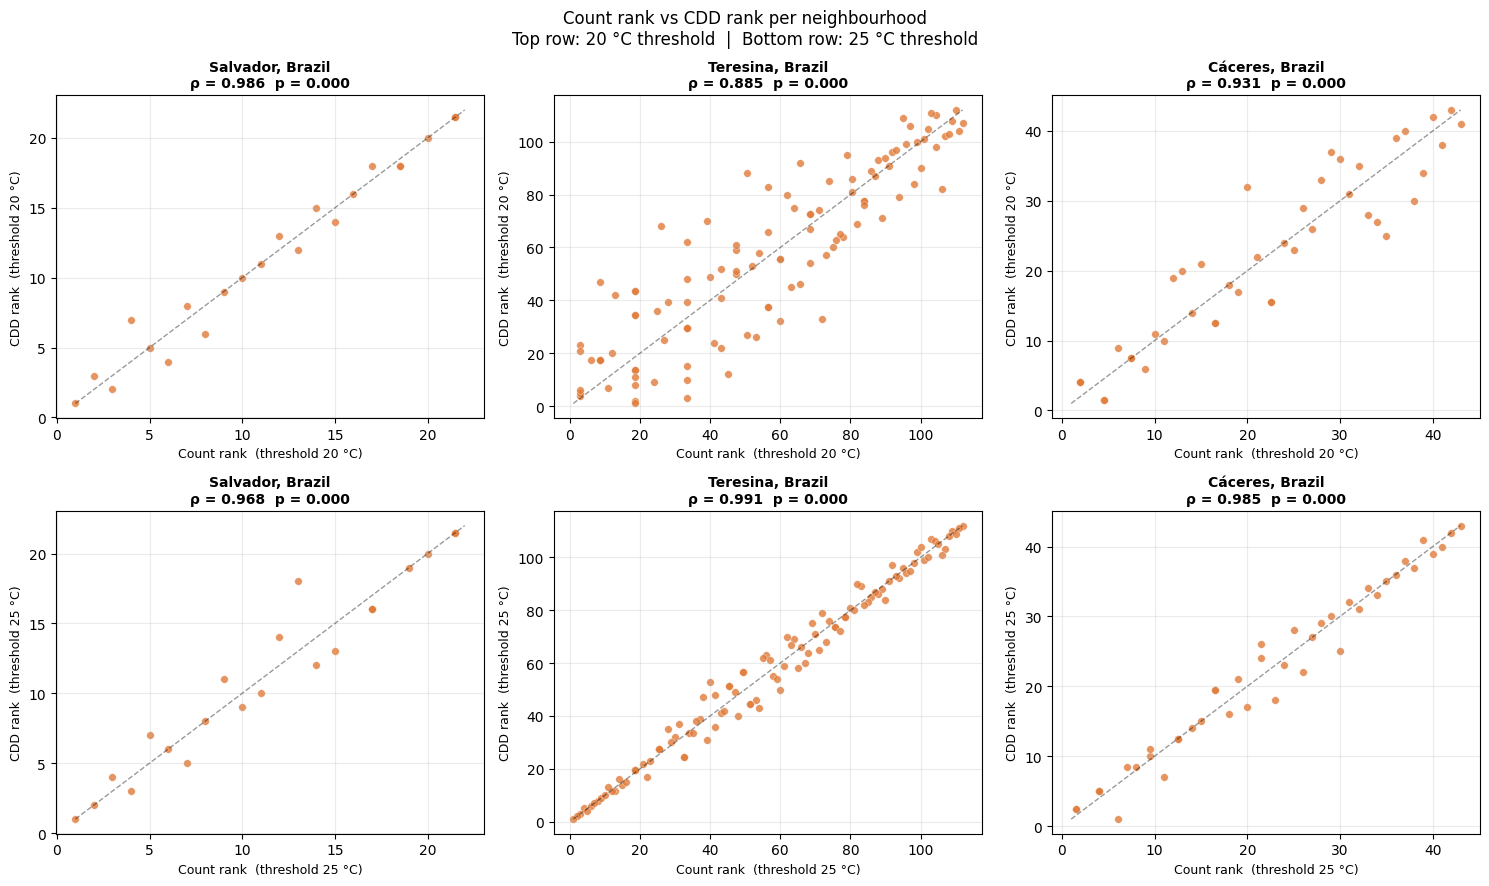

In [26]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=False)
fig.suptitle(
    'Count rank vs CDD rank per neighbourhood\n'
    'Top row: 20 °C threshold  |  Bottom row: 25 °C threshold',
    fontsize=12,
)

for col_idx, (thr_label, count_col, cdd_col) in enumerate([
    ('20 °C', 'CDD20_count', 'CDD20_cdd'),
    ('25 °C', 'CDD25_count', 'CDD25_cdd'),
]):
    for row_idx, c in enumerate(CITY_KEYS):
        ax  = axes[col_idx][row_idx]
        df  = nbhd_tables[c]
        n   = len(df)

        rho, pval = spearmanr(df[count_col], df[cdd_col])

        rank_count = df[count_col].rank(ascending=False)
        rank_cdd   = df[cdd_col].rank(ascending=False)

        ax.scatter(rank_count, rank_cdd, s=30, alpha=0.8, color='#e07b39', edgecolors='white', linewidth=0.3)
        ax.plot([1, n], [1, n], 'k--', linewidth=1, alpha=0.4)
        ax.set_xlabel(f'Count rank  (threshold {thr_label})', fontsize=9)
        ax.set_ylabel(f'CDD rank  (threshold {thr_label})', fontsize=9)
        ax.set_title(
            f'{CITIES[c]["label"]}\nρ = {rho:.3f}  p = {pval:.3f}',
            fontsize=10, fontweight='bold',
        )
        ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## Neighbourhood distributions

Box plots showing the spread of each metric across neighbourhoods. Complements the CV numbers by revealing whether variation is driven by outliers or genuine spread.

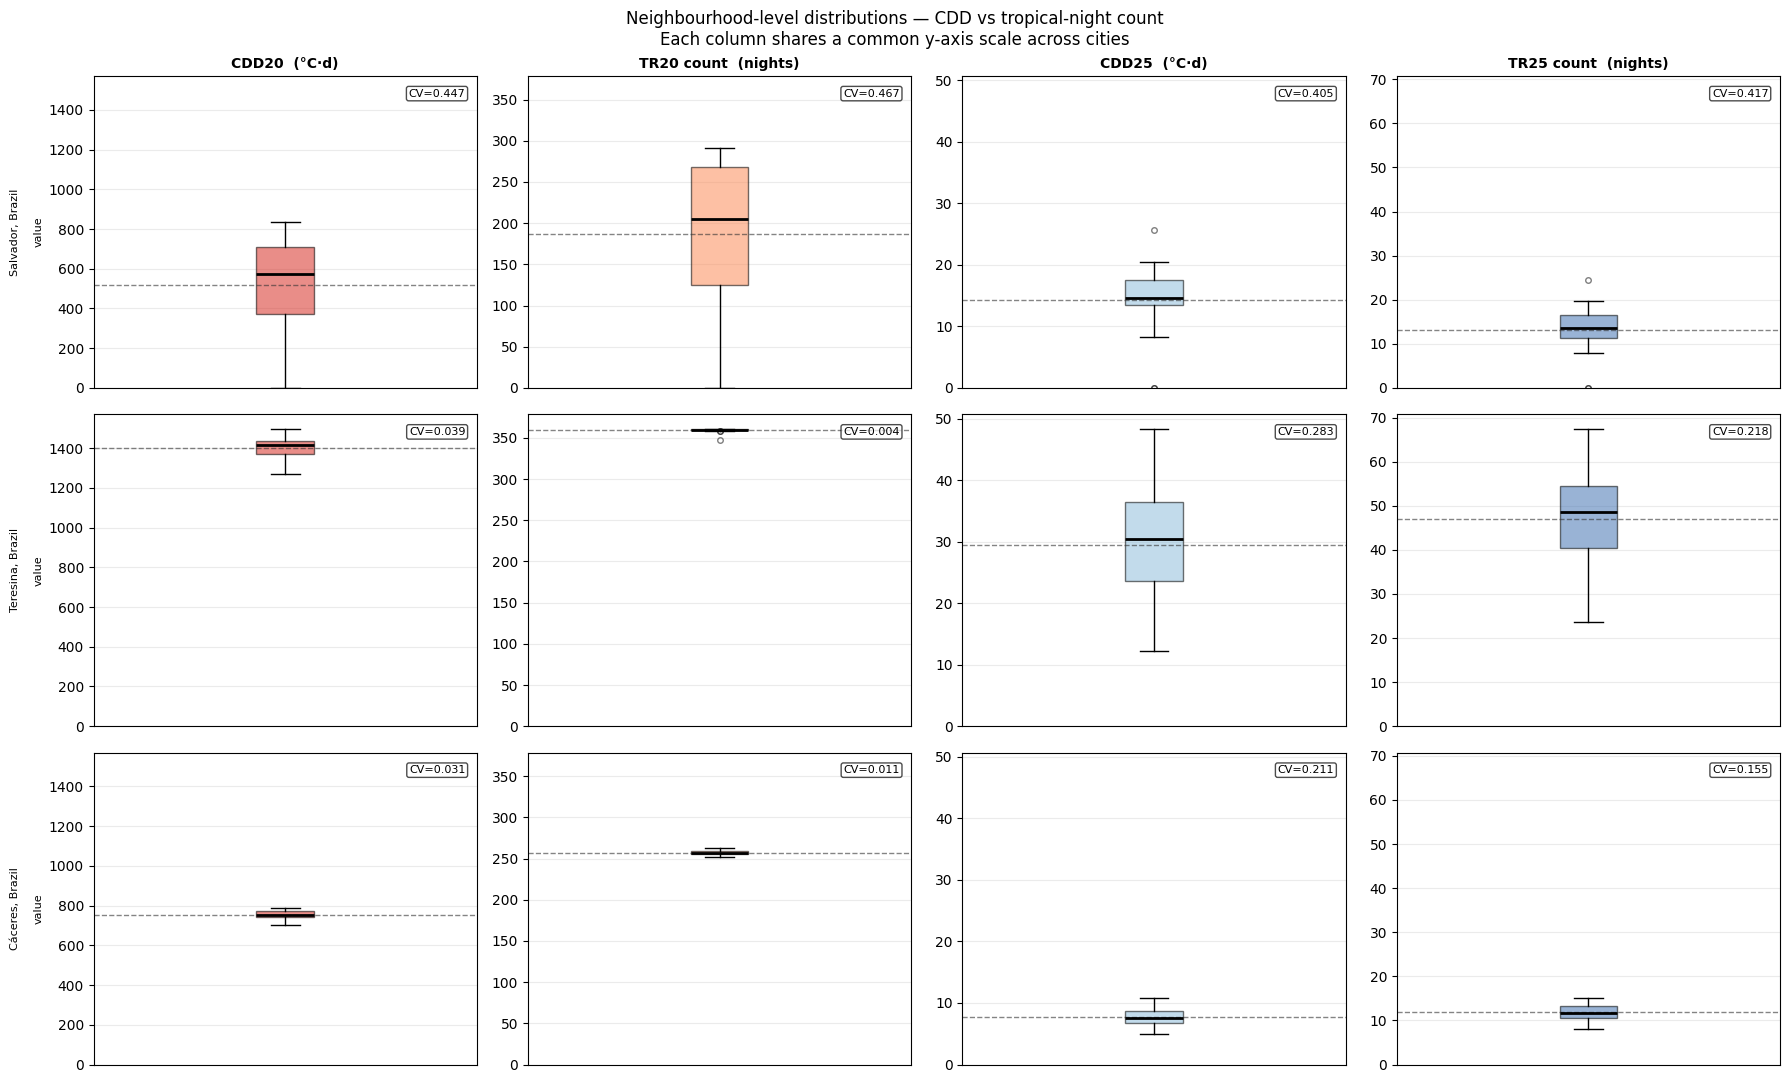

In [27]:
metric_ylims = {}
for col in metric_cols:
    all_vals = np.concatenate([nbhd_tables[c][col].dropna().values for c in CITY_KEYS])
    metric_ylims[col] = (float(all_vals.min()) * 0.9, float(all_vals.max()) * 1.05)

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
fig.suptitle(
    'Neighbourhood-level distributions — CDD vs tropical-night count\n'
    'Each column shares a common y-axis scale across cities',
    fontsize=12,
)

box_colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']

for row, c in enumerate(CITY_KEYS):
    df    = nbhd_tables[c]
    label = CITIES[c]['label']

    for col_idx, col in enumerate(metric_cols):
        ax   = axes[row][col_idx]
        vals = df[col].dropna().values
        mean = vals.mean()
        cv   = vals.std() / mean if mean > 0 else 0

        ax.boxplot(
            vals, vert=True, patch_artist=True,
            boxprops=dict(facecolor=box_colors[col_idx], alpha=0.55),
            medianprops=dict(color='black', linewidth=2),
            whiskerprops=dict(linewidth=1),
            flierprops=dict(marker='o', markersize=4, alpha=0.5),
        )
        ax.axhline(mean, color='#333333', linewidth=1, linestyle='--', alpha=0.6)

        ylo, yhi = metric_ylims[col]
        ax.set_ylim(ylo, yhi)
        ax.set_xticks([])
        ax.grid(True, axis='y', alpha=0.25)

        if row == 0:
            ax.set_title(metric_labels[col], fontsize=10, fontweight='bold', pad=6)
        if col_idx == 0:
            ax.set_ylabel(f'{label}\n\nvalue', fontsize=8)

        ax.text(
            0.97, 0.96, f'CV={cv:.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7),
        )

plt.tight_layout()
plt.show()

## Neighbourhood maps: CDD20 and CDD25

Choropleth maps of population-weighted mean CDD per neighbourhood. Colour scale is set independently per city (each city uses its own min–max range) so that within-city spatial structure is visible regardless of the absolute difference in CDD values between cities. Shared scales across cities would wash out the signal in lower-CDD cities.

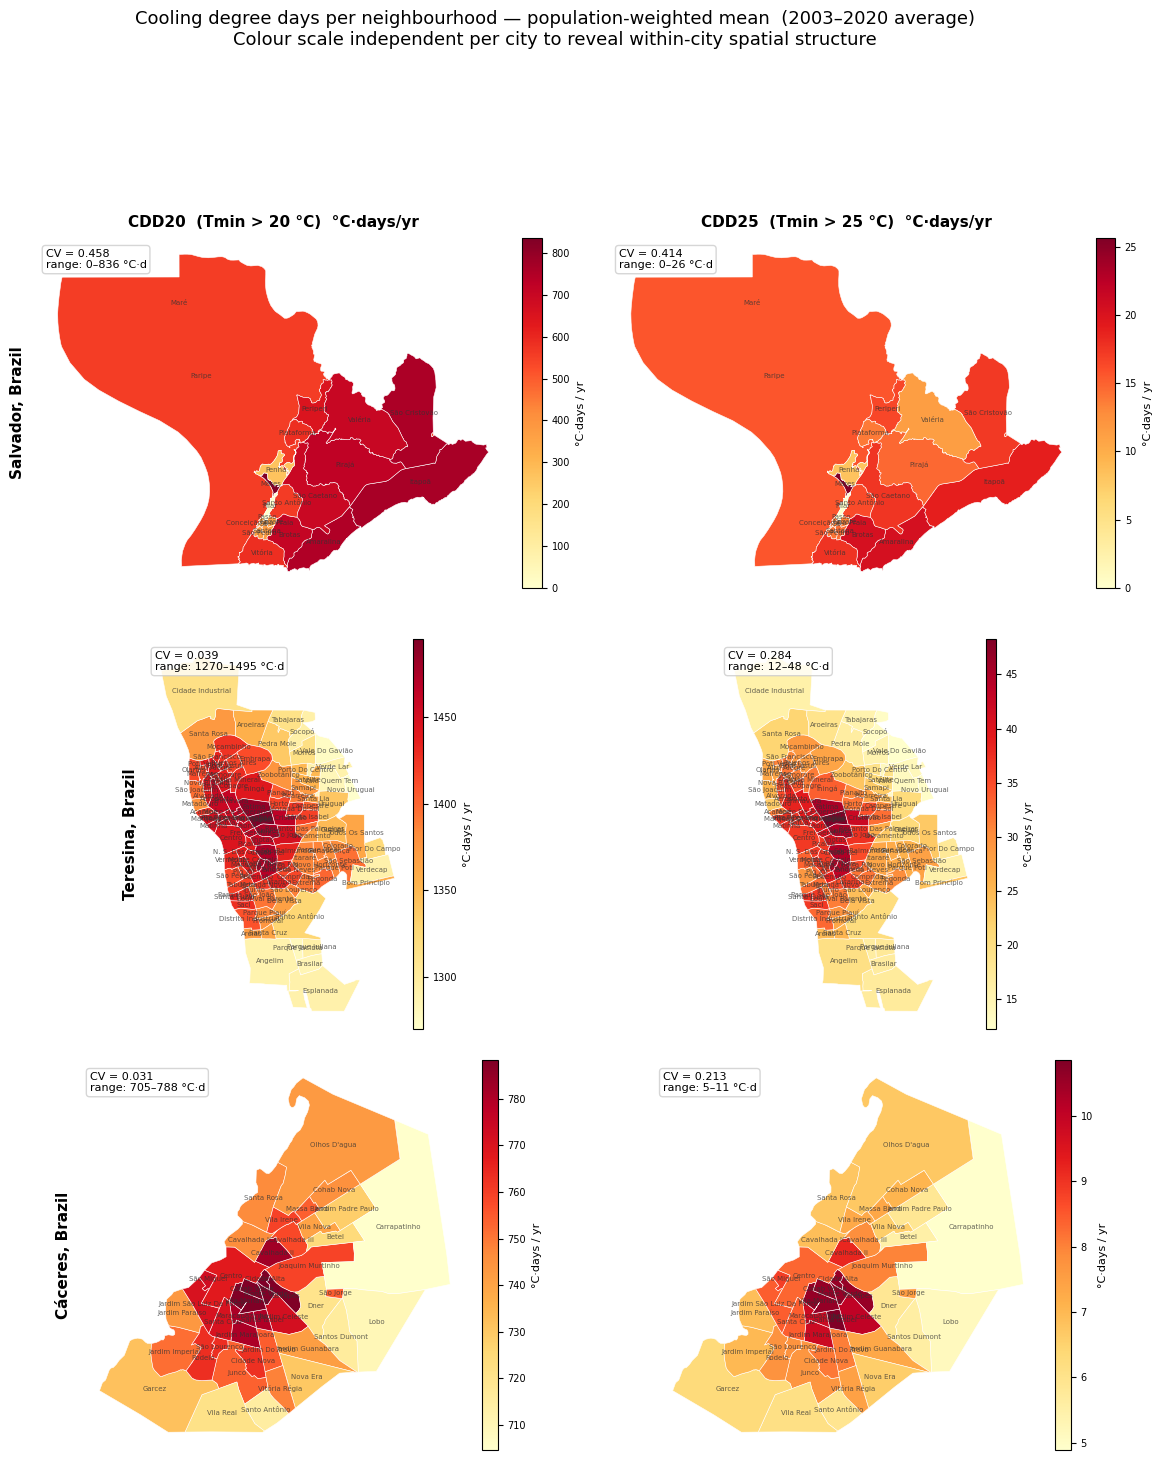

Saved: figures/16_cdd_neighbourhood_maps.png


In [28]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from mpl_toolkits.axes_grid1 import make_axes_locatable

CMAP     = 'YlOrRd'
PLOT_COLS = [('CDD20_cdd', 'CDD20  (Tmin > 20 °C)  °C·days/yr'),
             ('CDD25_cdd', 'CDD25  (Tmin > 25 °C)  °C·days/yr')]

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 16),
    gridspec_kw={'hspace': 0.08, 'wspace': 0.12},
)
fig.suptitle(
    'Cooling degree days per neighbourhood — population-weighted mean  (2003–2020 average)\n'
    'Colour scale independent per city to reveal within-city spatial structure',
    fontsize=13, y=1.01,
)

for row, c in enumerate(CITY_KEYS):
    gdf   = gdfs[c]
    df    = nbhd_tables[c]
    label = CITIES[c]['label']

    # Merge CDD values back to geometry
    plot_gdf = gdf.merge(df[['name', 'CDD20_cdd', 'CDD25_cdd']], on='name', how='left')

    for col_idx, (col, col_title) in enumerate(PLOT_COLS):
        ax = axes[row][col_idx]

        vals      = plot_gdf[col].dropna()
        vmin, vmax = vals.min(), vals.max()
        cv         = safe_cv(df[col])

        # Avoid degenerate colorbar when all values are identical
        if vmax - vmin < 1e-6:
            vmin, vmax = vmin - 0.5, vmax + 0.5

        plot_gdf.plot(
            column=col,
            ax=ax,
            cmap=CMAP,
            vmin=vmin,
            vmax=vmax,
            edgecolor='white',
            linewidth=0.4,
            missing_kwds={'color': '#cccccc', 'label': 'No data'},
        )

        # Colorbar fitted to the axes
        sm = plt.cm.ScalarMappable(
            cmap=CMAP,
            norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
        )
        sm.set_array([])
        divider = make_axes_locatable(ax)
        cax     = divider.append_axes('right', size='4%', pad=0.06)
        cb      = fig.colorbar(sm, cax=cax)
        cb.set_label('°C·days / yr', fontsize=8)
        cb.ax.tick_params(labelsize=7)

        # Annotate each neighbourhood with its name (small, centred on polygon)
        for _, row_geom in plot_gdf.iterrows():
            if row_geom.geometry is not None and row_geom[col] == row_geom[col]:
                cx = row_geom.geometry.centroid.x
                cy = row_geom.geometry.centroid.y
                ax.annotate(
                    row_geom['name'],
                    xy=(cx, cy),
                    fontsize=5,
                    ha='center',
                    va='center',
                    color='#333333',
                    alpha=0.75,
                )

        # City label on left column only
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=11, fontweight='bold', labelpad=8)

        # Column title on top row only
        if row == 0:
            ax.set_title(col_title, fontsize=11, fontweight='bold', pad=8)

        # CV annotation
        ax.text(
            0.02, 0.97,
            f'CV = {cv:.3f}\nrange: {vmin:.0f}–{vmax:.0f} °C·d',
            transform=ax.transAxes,
            fontsize=8,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8, ec='#cccccc'),
        )

        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.savefig('figures/16_cdd_neighbourhood_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/16_cdd_neighbourhood_maps.png')

## Summary table: CDD gain over count

Direct comparison of CV improvement from count → CDD at each threshold and city.

In [29]:
gain_rows = []
for c in CITY_KEYS:
    df = nbhd_tables[c]
    cv20_count = safe_cv(df['CDD20_count'])
    cv20_cdd   = safe_cv(df['CDD20_cdd'])
    cv25_count = safe_cv(df['CDD25_count'])
    cv25_cdd   = safe_cv(df['CDD25_cdd'])

    gain_rows.append({
        'City':                    CITIES[c]['label'],
        'CV TR20 count':           cv20_count,
        'CV CDD20':                cv20_cdd,
        'CDD20 gain (×)':          cv20_cdd / cv20_count if cv20_count > 0 else np.nan,
        'CV TR25 count':           cv25_count,
        'CV CDD25':                cv25_cdd,
        'CDD25 gain (×)':          cv25_cdd / cv25_count if cv25_count > 0 else np.nan,
    })

gain_df = pd.DataFrame(gain_rows).set_index('City')

cv_cols_g   = ['CV TR20 count', 'CV CDD20', 'CV TR25 count', 'CV CDD25']
gain_cols_g = ['CDD20 gain (×)', 'CDD25 gain (×)']

fmt_g = {c: '{:.3f}' for c in cv_cols_g}
fmt_g.update({c: '{:.2f}×' for c in gain_cols_g})

display(
    gain_df.style
    .format(fmt_g)
    .background_gradient(subset=cv_cols_g,   cmap='YlOrRd', axis=None)
    .background_gradient(subset=gain_cols_g, cmap='YlGn',   axis=None, vmin=1.0)
    .set_caption(
        'CDD gain = CV(CDD) / CV(count)  |  >1× means CDD has more spatial discrimination than count  |  '
        'Multi-year means 2003–2020, pop-weighted neighbourhood aggregation'
    )
    .set_table_styles(table_styles)
)

,CV TR20 count,CV CDD20,CDD20 gain (×),CV TR25 count,CV CDD25,CDD25 gain (×)
City,,,,,,
"Salvador, Brazil",0.478,0.458,0.96×,0.427,0.414,0.97×
"Teresina, Brazil",0.004,0.039,11.03×,0.219,0.284,1.30×
"Cáceres, Brazil",0.012,0.031,2.71×,0.157,0.213,1.36×


## Interpretation

In [30]:
from IPython.display import Markdown

# ---- Benchmark CVs from notebooks 12 and 13 --------------------------------
BENCHMARKS = {
    'salvador': {'tx90p_hd': 0.485, 'ehf_tmin': 0.431},
    'teresina': {'tx90p_hd': 0.009, 'ehf_tmin': 0.141},
    'caceres':  {'tx90p_hd': 0.008, 'ehf_tmin': 0.073},
}

_SAT = 0.05   # CV below this = effectively saturated

def _interpret_city(c):
    df     = nbhd_tables[c]
    label  = CITIES[c]['label']
    bench  = BENCHMARKS[c]

    cv20c  = safe_cv(df['CDD20_count'])
    cv20d  = safe_cv(df['CDD20_cdd'])
    cv25c  = safe_cv(df['CDD25_count'])
    cv25d  = safe_cv(df['CDD25_cdd'])
    g20    = cv20d / cv20c if cv20c > 0 else float('nan')
    g25    = cv25d / cv25c if cv25c > 0 else float('nan')

    ehf_cv  = bench['ehf_tmin']
    lines   = [f'**{label}**']

    # -- CDD20 vs TR20 count --
    if cv20c < _SAT:
        lines.append(
            f'TR20 count is saturated (CV = {cv20c:.3f}) — nearly every neighbourhood '
            f'crosses the 20 °C threshold on the same number of nights, leaving no spatial signal. '
            + (f'CDD20 also remains saturated (CV = {cv20d:.3f}) — accumulating excess degrees '
               f'does not recover information when the threshold is crossed almost everywhere.'
               if cv20d < _SAT else
               f'CDD20 recovers partial spatial variation (CV = {cv20d:.3f}, {g20:.1f}× gain over count) — '
               f'even though counts are flat, the *magnitude* of excess varies slightly across neighbourhoods.')
        )
    else:
        lines.append(
            f'TR20 count has useful spatial variation (CV = {cv20c:.3f}). '
            + (f'CDD20 improves on this (CV = {cv20d:.3f}, {g20:.1f}× gain) — '
               f'accumulating excess degrees amplifies the contrast between marginal and persistent exceeders.'
               if g20 > 1.05 else
               f'CDD20 offers negligible additional discrimination (CV = {cv20d:.3f}, {g20:.2f}× gain) — '
               f'counts and degree-days rank neighbourhoods almost identically at this threshold.')
        )

    # -- CDD25 vs TR25 count --
    if cv25c < _SAT:
        lines.append(
            f'TR25 count is also flat (CV = {cv25c:.3f}). '
            + (f'CDD25 remains uninformative (CV = {cv25d:.3f}).'
               if cv25d < _SAT else
               f'CDD25 lifts CV to {cv25d:.3f} ({g25:.1f}× gain over count) — '
               f'the 25 °C threshold is more selective and the residual intensity variation '
               f'above it begins to differentiate neighbourhoods.')
        )
    else:
        lines.append(
            f'TR25 count (CV = {cv25c:.3f}) is already informative. '
            + (f'CDD25 further improves discrimination (CV = {cv25d:.3f}, {g25:.1f}×).'
               if g25 > 1.05 else
               f'CDD25 (CV = {cv25d:.3f}) adds negligible gain ({g25:.2f}×) over the count.')
        )

    # -- Comparison with EHF(Tmin) benchmark --
    best_cdd = max(cv20d, cv25d)
    best_thr = '20 °C' if cv20d >= cv25d else '25 °C'
    ratio    = best_cdd / ehf_cv if ehf_cv > 0 else float('nan')

    if ratio >= 1.10:
        lines.append(
            f'**CDD at {best_thr} (CV = {best_cdd:.3f}) outperforms EHF(Tmin) '
            f'(CV = {ehf_cv:.3f}) by {ratio:.1f}×.** '
            f'The simpler absolute-threshold cumulative metric actually produces *more* '
            f'spatial discrimination than EHF for this city. '
            f'CDD is the recommended metric here — it is more discriminating and far easier to communicate.'
        )
    elif ratio >= 0.90:
        lines.append(
            f'Best CDD (CDD at {best_thr}, CV = {best_cdd:.3f}) is within 10% of '
            f'EHF(Tmin) (CV = {ehf_cv:.3f}) — CDD is a viable, more communicable '
            f'alternative to EHF for this city with no meaningful loss of spatial discrimination.'
        )
    elif ratio >= 0.50:
        lines.append(
            f'Best CDD (CDD at {best_thr}, CV = {best_cdd:.3f}) reaches {100*ratio:.0f}% '
            f'of EHF(Tmin) CV ({ehf_cv:.3f}). CDD captures part of the spatial signal but '
            f"EHF's 30-day acclimatisation window adds meaningful additional discrimination — "
            f'consider exposing both.'
        )
    else:
        lines.append(
            f'Best CDD (CDD at {best_thr}, CV = {best_cdd:.3f}) reaches only '
            f'{100*ratio:.0f}% of EHF(Tmin) CV ({ehf_cv:.3f}). '
            f'The acclimatisation component of EHF is doing substantial work that a fixed '
            f'absolute threshold cannot recover — EHF(Tmin) remains the preferred hazard metric.'
        )

    return '\n\n'.join(lines)


# ---- Cross-city summary table -----------------------------------------------
summary_rows = []
for c in CITY_KEYS:
    df = nbhd_tables[c]
    b  = BENCHMARKS[c]
    cv20d = safe_cv(df['CDD20_cdd'])
    cv25d = safe_cv(df['CDD25_cdd'])
    best  = max(cv20d, cv25d)
    summary_rows.append({
        'City':                CITIES[c]['label'],
        'CV TX90p (nb12)':     b['tx90p_hd'],
        'CV EHF Tmin (nb13)':  b['ehf_tmin'],
        'CV CDD20':            cv20d,
        'CV CDD25':            cv25d,
        'Best CDD vs EHF (×)': best / b['ehf_tmin'] if b['ehf_tmin'] > 0 else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).set_index('City')
cv_sum_cols = ['CV TX90p (nb12)', 'CV EHF Tmin (nb13)', 'CV CDD20', 'CV CDD25']

display(
    summary_df.style
    .format({c: '{:.3f}' for c in cv_sum_cols} | {'Best CDD vs EHF (×)': '{:.2f}×'})
    .background_gradient(subset=cv_sum_cols, cmap='YlOrRd', axis=None)
    .set_caption(
        'Cross-metric CV comparison  |  CDD benchmarked against TX90p (nb12) and EHF(Tmin) (nb13)  |  '
        'Best CDD vs EHF: >1× means CDD outperforms EHF on spatial discrimination'
    )
    .set_table_styles(table_styles)
)

# ---- Narrative per city -----------------------------------------------------
city_blocks = '\n\n---\n\n'.join(_interpret_city(c) for c in CITY_KEYS)

display(Markdown(f'''
### City-by-city findings

{city_blocks}

---

### Implication for the platform hazard layer

Use the **Best CDD vs EHF (×)** column above to decide:

- **> 1.10×** — CDD outperforms EHF(Tmin) on spatial discrimination. Use CDD: simpler to compute, easier to explain ("X °C·days above 25 °C per year"), and more discriminating.
- **0.90–1.10×** — CDD and EHF are equivalent. Prefer CDD for communication; use EHF only if the acclimatisation framing matters for the audience.
- **0.50–0.89×** — CDD captures part of the signal. Consider exposing both: CDD for public-facing output, EHF as the analytical ranking layer.
- **< 0.50×** — EHF(Tmin) is the only metric with adequate spatial discrimination. CDD at a fixed threshold cannot substitute.
'''))

,CV TX90p (nb12),CV EHF Tmin (nb13),CV CDD20,CV CDD25,Best CDD vs EHF (×)
City,,,,,
"Salvador, Brazil",0.485,0.431,0.458,0.414,1.06×
"Teresina, Brazil",0.009,0.141,0.039,0.284,2.01×
"Cáceres, Brazil",0.008,0.073,0.031,0.213,2.92×



### City-by-city findings

**Salvador, Brazil**

TR20 count has useful spatial variation (CV = 0.478). CDD20 offers negligible additional discrimination (CV = 0.458, 0.96× gain) — counts and degree-days rank neighbourhoods almost identically at this threshold.

TR25 count (CV = 0.427) is already informative. CDD25 (CV = 0.414) adds negligible gain (0.97×) over the count.

Best CDD (CDD at 20 °C, CV = 0.458) is within 10% of EHF(Tmin) (CV = 0.431) — CDD is a viable, more communicable alternative to EHF for this city with no meaningful loss of spatial discrimination.

---

**Teresina, Brazil**

TR20 count is saturated (CV = 0.004) — nearly every neighbourhood crosses the 20 °C threshold on the same number of nights, leaving no spatial signal. CDD20 also remains saturated (CV = 0.039) — accumulating excess degrees does not recover information when the threshold is crossed almost everywhere.

TR25 count (CV = 0.219) is already informative. CDD25 further improves discrimination (CV = 0.284, 1.3×).

**CDD at 25 °C (CV = 0.284) outperforms EHF(Tmin) (CV = 0.141) by 2.0×.** The simpler absolute-threshold cumulative metric actually produces *more* spatial discrimination than EHF for this city. CDD is the recommended metric here — it is more discriminating and far easier to communicate.

---

**Cáceres, Brazil**

TR20 count is saturated (CV = 0.012) — nearly every neighbourhood crosses the 20 °C threshold on the same number of nights, leaving no spatial signal. CDD20 also remains saturated (CV = 0.031) — accumulating excess degrees does not recover information when the threshold is crossed almost everywhere.

TR25 count (CV = 0.157) is already informative. CDD25 further improves discrimination (CV = 0.213, 1.4×).

**CDD at 25 °C (CV = 0.213) outperforms EHF(Tmin) (CV = 0.073) by 2.9×.** The simpler absolute-threshold cumulative metric actually produces *more* spatial discrimination than EHF for this city. CDD is the recommended metric here — it is more discriminating and far easier to communicate.

---

### Implication for the platform hazard layer

Use the **Best CDD vs EHF (×)** column above to decide:

- **> 1.10×** — CDD outperforms EHF(Tmin) on spatial discrimination. Use CDD: simpler to compute, easier to explain ("X °C·days above 25 °C per year"), and more discriminating.
- **0.90–1.10×** — CDD and EHF are equivalent. Prefer CDD for communication; use EHF only if the acclimatisation framing matters for the audience.
- **0.50–0.89×** — CDD captures part of the signal. Consider exposing both: CDD for public-facing output, EHF as the analytical ranking layer.
- **< 0.50×** — EHF(Tmin) is the only metric with adequate spatial discrimination. CDD at a fixed threshold cannot substitute.
